In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(42)
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 50: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        # We need a lot of history (400 days) to calculate the initial indicator
        if len(df) < 500:
            continue
            
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks.")


Loaded 50 stocks.


In [3]:
# 3. The Python Port of Pine Script (Stepline Logic)
def calculate_stepline(df):
    df = df.copy()
    
    lengthf = 200
    fast = 100
    slow = 400
    atr_length = 14
    sensitivity1 = 0.01
    
    # 1. ER Calculation
    change = abs(df['Close'] - df['Close'].shift(lengthf))
    volatility = df['Close'].diff().abs().rolling(lengthf).sum()
    df['ER'] = change / volatility
    
    # 2. Dynamic Deviation
    std_fast = (df['Close'] * 2).rolling(fast).std()
    std_slow = (df['Close'] * 2).rolling(slow).std()
    df['Dev'] = (df['ER'] * std_fast) + ((1 - df['ER']) * std_slow)
    
    # 3. ATR Calculation
    df['TR'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low'] - df['Close'].shift(1))
        )
    )
    df['ATR'] = df['TR'].rolling(atr_length).mean()
    
    # Extract to numpy arrays for fast looping
    close_arr = df['Close'].values
    dev_arr = df['Dev'].fillna(0).values
    atr_arr = df['ATR'].fillna(0).values
    
    n = len(df)
    a_arr = np.zeros(n)
    trend_arr = np.zeros(n)
    
    current_a = 0.0
    current_trend = 0
    
    for i in range(1, n):
        src = close_arr[i]
        dev = dev_arr[i]
        
        # Calculate Stepline A
        if src > current_a + dev:
            a_arr[i] = src
        elif src < current_a - dev:
            a_arr[i] = src
        else:
            a_arr[i] = current_a
            
        current_a = a_arr[i]
        
        # Calculate Trend
        prev_a = a_arr[i-1]
        delta = (current_a - prev_a) / prev_a if prev_a != 0 else 0
        
        price_scale = current_a if current_a != 0 else src
        volatility_pct = atr_arr[i] / price_scale if price_scale != 0 else 0
        threshold = volatility_pct * sensitivity1
        
        if abs(delta) >= threshold:
            current_trend = 1 if delta > 0 else 0
            
        trend_arr[i] = current_trend
        
    df['Stepline_A'] = a_arr
    df['Is_Bullish'] = trend_arr
    
    return df

enriched_data = pd.concat([calculate_stepline(grp) for sym, grp in data.groupby('Symbol')], ignore_index=True)

# Shift the Bullish signal so we trade on the next day's open/close after signal is generated
enriched_data['Buy_Signal'] = (enriched_data['Is_Bullish'] == 1) & (enriched_data['Is_Bullish'].shift(1) == 0)
enriched_data['Sell_Signal'] = (enriched_data['Is_Bullish'] == 0) & (enriched_data['Is_Bullish'].shift(1) == 1)


In [4]:
# 4. Backtest the Trend Following System (Unseen 2023+ Data)
test_data = enriched_data[enriched_data['Date'] >= '2023-01-01'].reset_index(drop=True)

trades = []

for symbol in test_data['Symbol'].unique():
    stock_df = test_data[test_data['Symbol'] == symbol].reset_index(drop=True)
    
    in_trade = False
    entry_price = 0
    entry_date = None
    
    for i, row in stock_df.iterrows():
        if not in_trade and row['Buy_Signal']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
        
        elif in_trade and row['Sell_Signal']:
            in_trade = False
            exit_price = row['Close']
            exit_date = row['Date']
            
            profit_pct = (exit_price - entry_price) / entry_price * 100
            days_held = (exit_date - entry_date).days
            
            trades.append({
                'Symbol': symbol,
                'Entry_Date': entry_date,
                'Exit_Date': exit_date,
                'Days_Held': days_held,
                'Profit_Pct': profit_pct
            })

trades_df = pd.DataFrame(trades)

print("\n=== STEPLINE TREND FOLLOWING RESULTS (2023+) ===")
if len(trades_df) > 0:
    win_rate = (trades_df['Profit_Pct'] > 0).mean() * 100
    avg_ret = trades_df['Profit_Pct'].mean()
    avg_hold = trades_df['Days_Held'].mean()
    print(f"Total Trades: {len(trades_df)}")
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Average Profit per Trade: {avg_ret:.2f}%")
    print(f"Average Holding Period: {avg_hold:.0f} days")
else:
    print("Zero trades executed. The lookback parameters (400 days) are too slow to trigger in this timeframe.")



=== STEPLINE TREND FOLLOWING RESULTS (2023+) ===
Total Trades: 806
Win Rate: 34.00%
Average Profit per Trade: 0.78%
Average Holding Period: 18 days


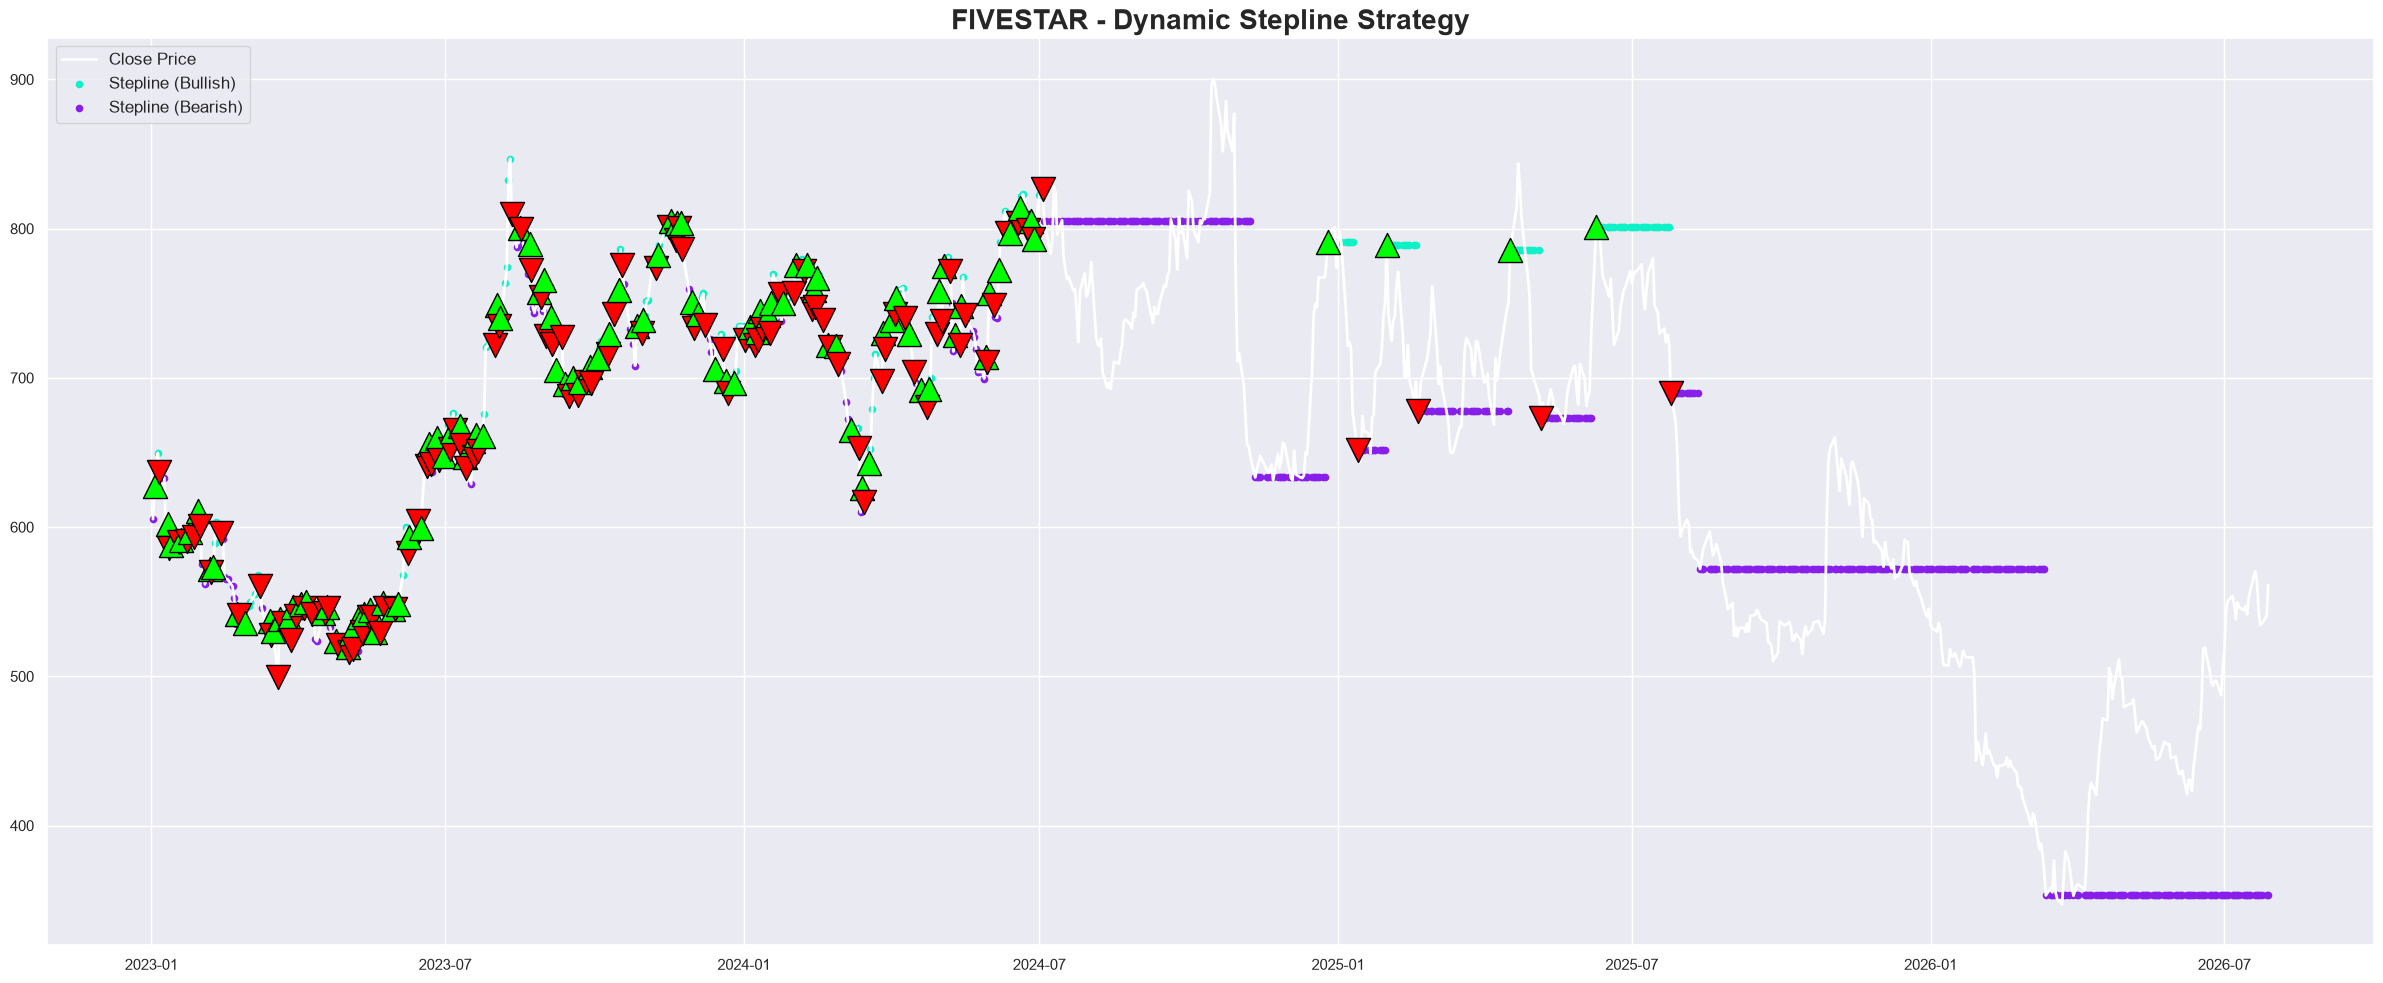

In [5]:
# 5. Visualizer
if len(trades_df) > 0:
    # Pick the stock with the most trades for visualization
    sample_symbol = trades_df['Symbol'].value_counts().index[0]
    plot_df = test_data[test_data['Symbol'] == sample_symbol].reset_index(drop=True)
    stock_trades = trades_df[trades_df['Symbol'] == sample_symbol]

    fig, ax1 = plt.subplots(figsize=(24, 10))

    # Price Line
    ax1.plot(plot_df['Date'], plot_df['Close'], label='Close Price', color='white', linewidth=2, zorder=3)
    
    # Stepline
    bullish_mask = plot_df['Is_Bullish'] == 1
    ax1.scatter(plot_df['Date'][bullish_mask], plot_df['Stepline_A'][bullish_mask], color='#0df1c6', s=20, label='Stepline (Bullish)')
    ax1.scatter(plot_df['Date'][~bullish_mask], plot_df['Stepline_A'][~bullish_mask], color='#871ee9', s=20, label='Stepline (Bearish)')

    # Entries and Exits
    for idx, trade in stock_trades.iterrows():
        ax1.scatter(trade['Entry_Date'], plot_df.loc[plot_df['Date'] == trade['Entry_Date'], 'Close'].values[0], color='lime', marker='^', s=300, zorder=5, edgecolors='black')
        ax1.scatter(trade['Exit_Date'], plot_df.loc[plot_df['Date'] == trade['Exit_Date'], 'Close'].values[0], color='red', marker='v', s=300, zorder=5, edgecolors='black')

    ax1.set_title(f"{sample_symbol} - Dynamic Stepline Strategy", fontsize=20, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.show()
